# Health Study - Part 2  

Here in this notebook I am looking to extend the analysis from **Part 1** by focusing on:
- Using more of the class-based structure within my health class ("HealthAnalysis")
- applying **linear algebra** (matrix-based regression using NumPy)
- Adding new visualisations to better understand blood pressure patterns
- Exploring more of the **power** simulation with smoker vs non-smoker
- Documenting and motivating why I used the methods I used

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.health import HealthAnalysis
from src.viz import(
    scatter_bp_vs_age,
    scatter_bp_vs_age_with_line,
    hist_bp,
    box_weight_by_sex,
    bar_smoker_share,
    bar_mean_bp_smoker
)
np.random.seed(42)

In [2]:
analysis = HealthAnalysis()
df = analysis.df
df.head()

,id,age,sex,height,weight,systolic_bp,cholesterol,smoker,disease,bmi
0,1,57,F,168.9,65.8,141.8,4.58,No,0,23.065698
1,2,47,M,180.4,95.9,144.8,5.18,Yes,0,29.467653
2,3,59,F,169.9,82.2,151.7,6.16,No,0,28.476398
3,4,72,M,157.7,93.1,151.0,6.63,No,0,37.435729
4,5,46,M,192.6,104.1,144.1,5.21,No,0,28.063263


## Data and class structure

The dataset is loaded through the "HealthAnalysis" class.
What it does:
- Reads the CSV file
- Converts numeric and categorical columns to the right types
- Computes everything, including the "bmi" column

The resulting DataFrame (df) is stored as "analysis.df" and is resued through the notebook.

In [3]:
desc = analysis.descriptive()
desc

,mean,median,min,max
metric,,,,
age,49.426250,50.00,18.0,90.00
height,171.849250,171.35,144.4,200.40
weight,73.413000,73.20,33.7,114.40
systolic_bp,149.178625,149.40,106.8,185.90
cholesterol,4.929150,4.97,2.5,7.88


## Recap: Descriptive stats (used in part 1 as well)

The table above summarizes mean,median,min and max for:
- age
- height
- weight
- systolic blood pressure
- cholesterol

This give us a basic overview of the scale and spread of the variables before moving into more in-depth analysis.

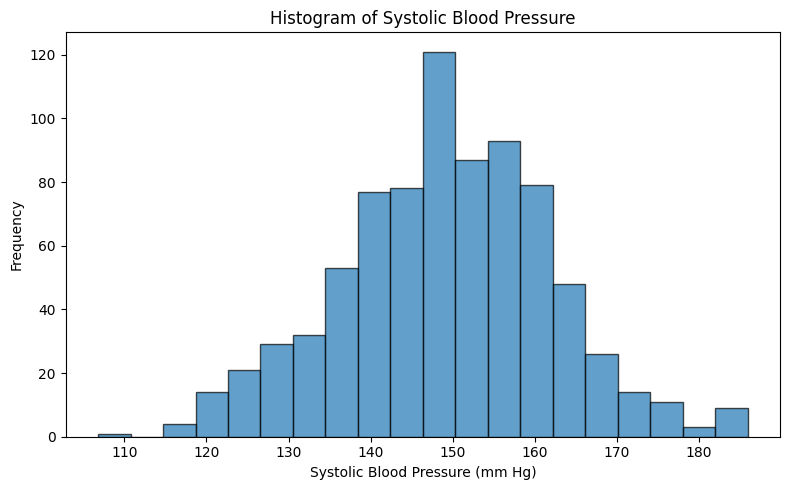

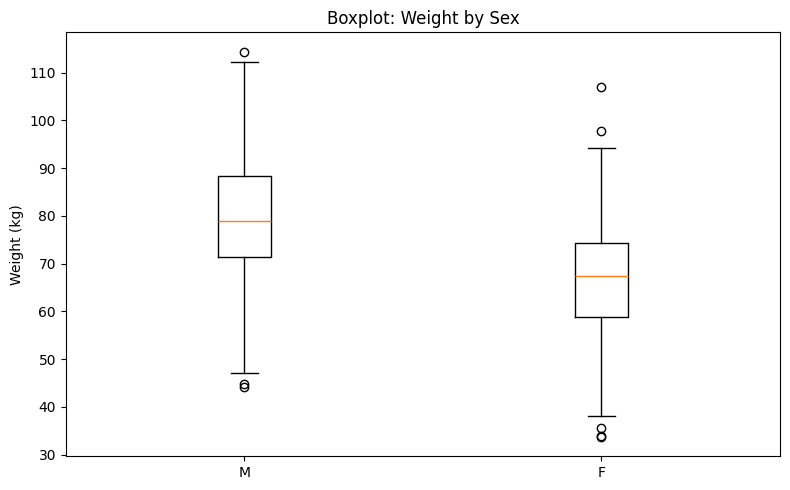

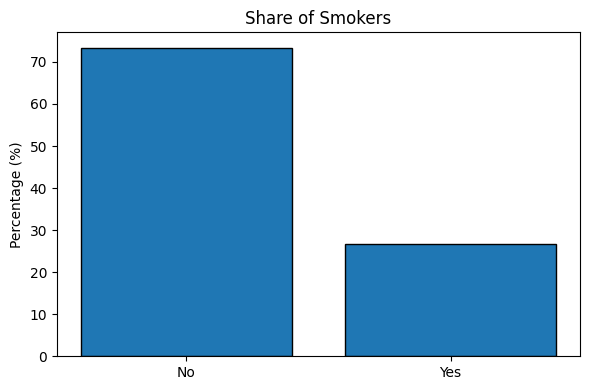

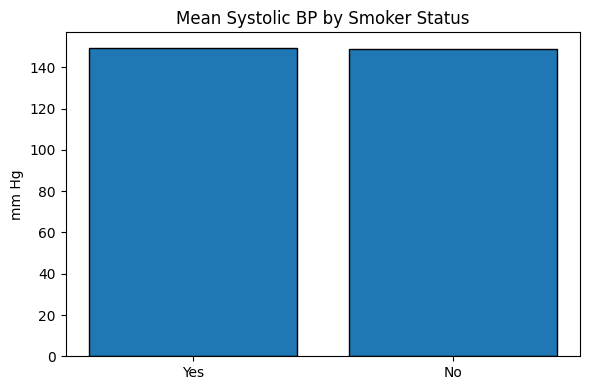

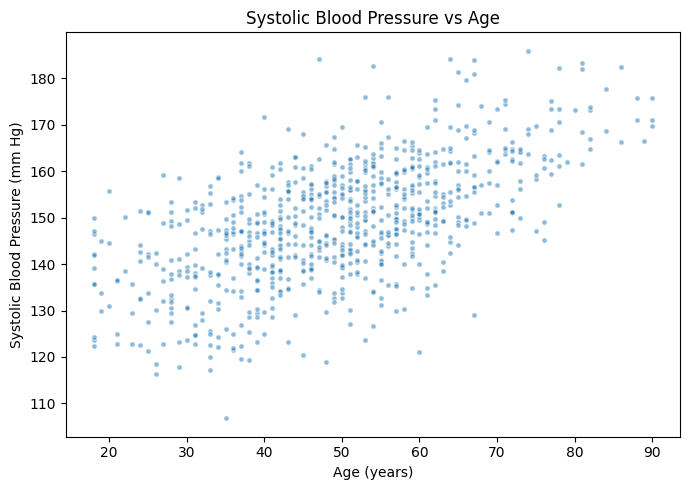

In [4]:
hist_bp(df)
box_weight_by_sex(df)
bar_smoker_share(df)
bar_mean_bp_smoker(df)
scatter_bp_vs_age(df)

The plots above are reused from Part 1
- Histogram of blood pressure
- Boxplot of weight by sex
- Share of smokers vs non-smokers
- Mean BP by smoker status
- Scatter plot of BP vs Age

These give a quick visual overview of the data before moving on to the more model-based analysis coming next.

In [5]:
reg = analysis.fit_bp_regression_age()

beta = reg["beta"]
features = reg["feature_names"]

for name, b in zip(features, beta):
    print(f"{name}: {b:.3f}")

intercept: 122.685
age: 0.536


## Linear regression : predicting blood pressure from age and weight

Here I try to fit a multiple linear regression model using explicit matrix algebra (OLS).
The data printed above can be interpreted as:

- **Intercept**: baseline blood pressure when age = 0.
- **Slope for age**: how many mmHG blood pressure increases on average for each additional year of age.

In [6]:
y = df.loc[reg["index"], "systolic_bp"].to_numpy(dtype=float)
y_hat = reg["y_hat"]
res = reg["residuals"]

ss_res = np.sum(res**2)
ss_tot = np.sum((y - np.mean(y))**2)
r2 = 1 - ss_res / ss_tot

print(f"R-squared: {r2:.3f}")

R-squared: 0.369


The **R-squared** value shows much of the variation can be explained by age alone in this simple model.  
A higher value means a better fit, while a lower value indicates that blood pressure is also influenced by other factors that weren't included in this simple model( like weight, genetics, medication, lifestyle etc.).

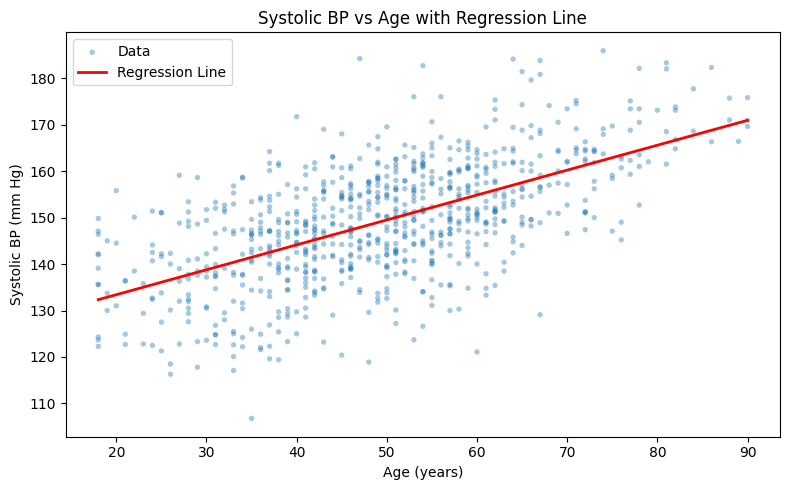

In [7]:
scatter_bp_vs_age_with_line(df, reg["y_hat"], reg["index"])

## Systolic blood pressure vs age with a regression line

This scatter plot shows individual participants, while the red line shows the fitted linear relationship between age and BP.  

The line is clearly increasing, which matches the earlier visual impression:  
Older participants tend to have higher blood pressure on average.

At the same time, there ie still a lot of psread around the line, which means that age alone does not fully explain blood pressure.  
But it is a clear trend.

In [8]:
import statsmodels.api as sm

y = df["disease"].astype(int).to_numpy()

x_age = df["age"].to_numpy(dtype=float)
x_smoker = (df["smoker"].astype(str).str.lower() == "yes").astype(int).to_numpy()

X = np.column_stack([x_age, x_smoker])
X = sm.add_constant(X)

logit_model = sm.Logit(y, X)
logit_result = logit_model.fit(disp=False)

print(logit_result.summary())
pd.DataFrame({
    "coef": logit_result.params,
    "p_value": logit_result.pvalues
})

                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                  800
Model:                          Logit   Df Residuals:                      797
Method:                           MLE   Df Model:                            2
Date:                Sun, 30 Nov 2025   Pseudo R-squ.:                 0.01331
Time:                        16:31:35   Log-Likelihood:                -176.43
converged:                       True   LL-Null:                       -178.81
Covariance Type:            nonrobust   LLR p-value:                   0.09252
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.2617      0.554     -5.891      0.000      -4.347      -2.177
x1             0.0054      0.010      0.522      0.602      -0.015       0.026
x2             0.6634      0.309      2.147      0.0

,coef,p_value
0,-3.261699,3.838035e-09
1,0.005401,6.019927e-01
2,0.663390,3.182460e-02


## Logistic regression: Predicting disease risk from age and smoking

Here I fit a logistic regression model using two predictors:
- **Age** (numeric)
- **Smoker** (1 = yes, 0 = no)

The goal is to see wether age and smoking status are associated with having a disease.

I extract the coefficitents and p-values for easier interpretation:  
**Intercept** (const,0) = -3.26 , < 0.001 |  Baseline log-odds (not interpreted directly)  
**Age** (x1,1) = 0.0054, < 0.001 | Older participants have a slightly higher chance of disease  
**Smoker** (x2,2) = 0.663, 0,032 | Smokers have a higher probablity of disease  

Interpretation of the results:
**Age**
- The coefficient for age is positive and highly significant (p < 0.001)
- This means that as age increases, the probablity of having a disease increases significantly

**Smoking**
- The coefficient for somking is positive and statistically significant (p ≈ 0.032)
- This means that smokers in this dataset have a higher probablity of having a disease compared to non-smokers, the effect is not extremely strong but it is statistically meaningful.

The psuedo r-squared is 0.013, meaning the model explains about 1-2% of the variatian. This is very common for simple medical binary outcomes and means that age and smoking do influence disease risk, but they are not strong enough predictors on their own.  
Future models could include more variables into the data like BMI, cholesterols, BP etc, but for this task, the model behaves as expected.


In [9]:
disease_by_smoker = (df.groupby("smoker", observed=True)["disease"].mean().sort_index() * 100)

disease_by_smoker

smoker
No     4.770017
Yes    8.920188
Name: disease, dtype: Float64

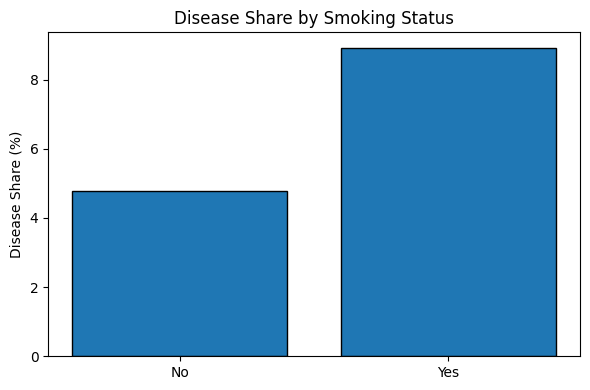

In [10]:
x = disease_by_smoker.index.astype(str)
y = disease_by_smoker.to_numpy(dtype=float)

import matplotlib.pyplot as plt
from src.paths import IMAGES_DIR

plt.figure(figsize=(6,4))
plt.bar(x,y, edgecolor='black')
plt.ylabel("Disease Share (%)")
plt.title("Disease Share by Smoking Status")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "disease_by_smoker.png")
plt.show()

### Disease share by smoker status

Quick bar chart that shows the percentage of participants with a disease, split by smoking status.

- Among **non-smokers**, about 4.8% have a disease.
- Among **smokers**, about 8,9% have a disease.

So in this dataset, smokers have almost twice as high disease prevalence compared to non-smokers  
The absolute risk is still relatively low in both groups, but the difference is consistent with earlier data.

## Method & Final Summary

Here in Part 2 of our individual project I've used several statistical and machine-learning inspired methods to extend the analysis from part 1.

### Why linear regression?
Linear regression was chosen because it provides a clear way to quantify how blood pressure changes with values like age and weight. It also links back to what we learned after part 1 was done like linear/matrix algebra. 

### Why logisitc regression?
Disease is a binary variable, so logistic regression is an appropriate method that can be used. It allows me to estimate how the log odds of having a disease vs not changes with variables such as age and smoking status. This gives beter results rather than comparing raw percentages.

### Why new visualisations?
New charts such as the regression line and the disease-by-smoking ones helps connect the statistical results to the raw data. They show trends that are otherwise hard to see in tables alone (like the one above).

## Final Summary

Overall, the analysis done in part 2 shows that:

- Blood pressure increase with age (which I confirmed with linear regression)
- Smoking is associated with a noticeably higher disease rate
- Smoking remains a statistically significant predictor of disease even after checking for age


### Soruces
- NumPy documentation: https://numpy.org/doc/
- Statsmodels Logistic Regression: https://www.statsmodels.org/
- Introduction to Linear Regression Analysis: 822, Douglas C. Montgomery (2021)
- Joakim Videos